In [5]:
import matplotlib.pyplot as plt
%ls log
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"


ls: cannot access 'log': No such file or directory


In [3]:
import json
import glob
import pandas as pd 
import numpy as np
dense_level = "5000x5000"
df = pd.read_csv("/home/jafar/Arts/Parallel-Dynamic-Sparse-Training/benchmark/log_mult_5.2kx5.2k.csv")
df

,isSparse,dense_level,sparsity_level,time,cuda_elapsed_time,rep,batch_size
0,JaxSparse,500x500,50.0,0.152213,152.132263,0,1
1,JaxSparse,500x500,50.0,0.035475,35.445854,1,1
2,JaxSparse,500x500,50.0,0.032312,32.300575,2,1
3,JaxSparse,500x500,50.0,0.035042,35.030594,3,1
4,JaxSparse,500x500,50.0,0.034179,34.161022,4,1
...,...,...,...,...,...,...,...
9355,SparseTorch,5200x5200,99.9,0.044542,44.753922,0,256
9356,SparseTorch,5200x5200,99.9,0.044091,44.297215,1,256
9357,SparseTorch,5200x5200,99.9,0.044066,44.275711,2,256
9358,SparseTorch,5200x5200,99.9,0.044067,44.272640,3,256


In [21]:
set(df['isSparse'])

{'Dense', 'JaxSparse', 'SparseTorch', 'SparseUT'}

/tmp/ipykernel_35863/3156453253.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dlvl['cuda_elapsed_time'] = df_dlvl['cuda_elapsed_time']# .apply(lambda x: np.log2(x))


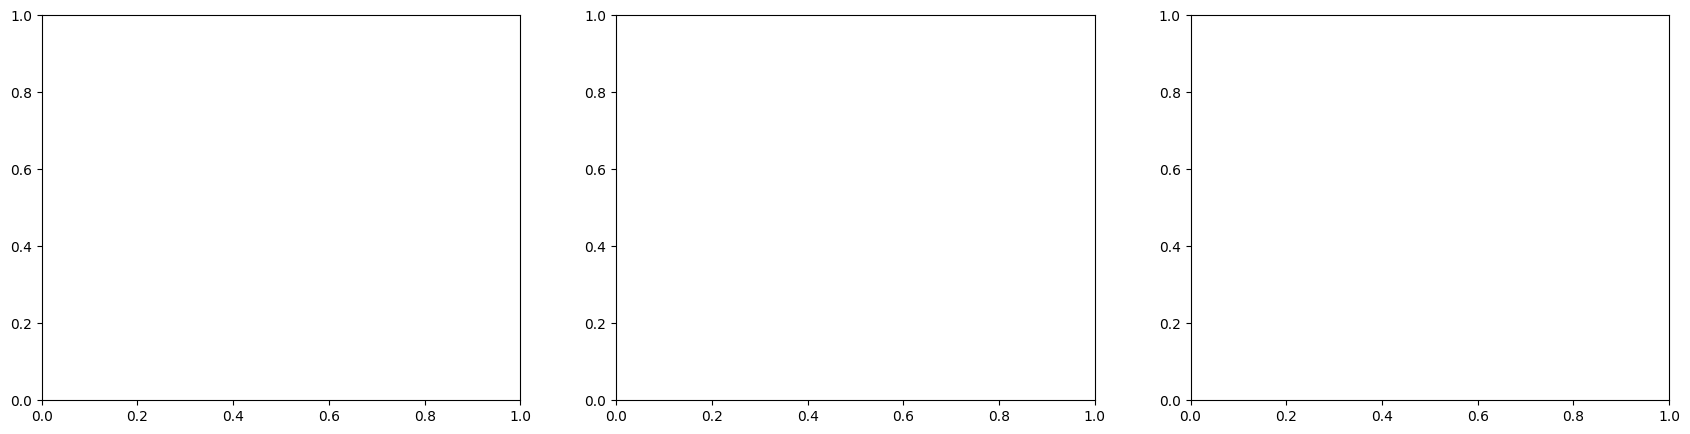

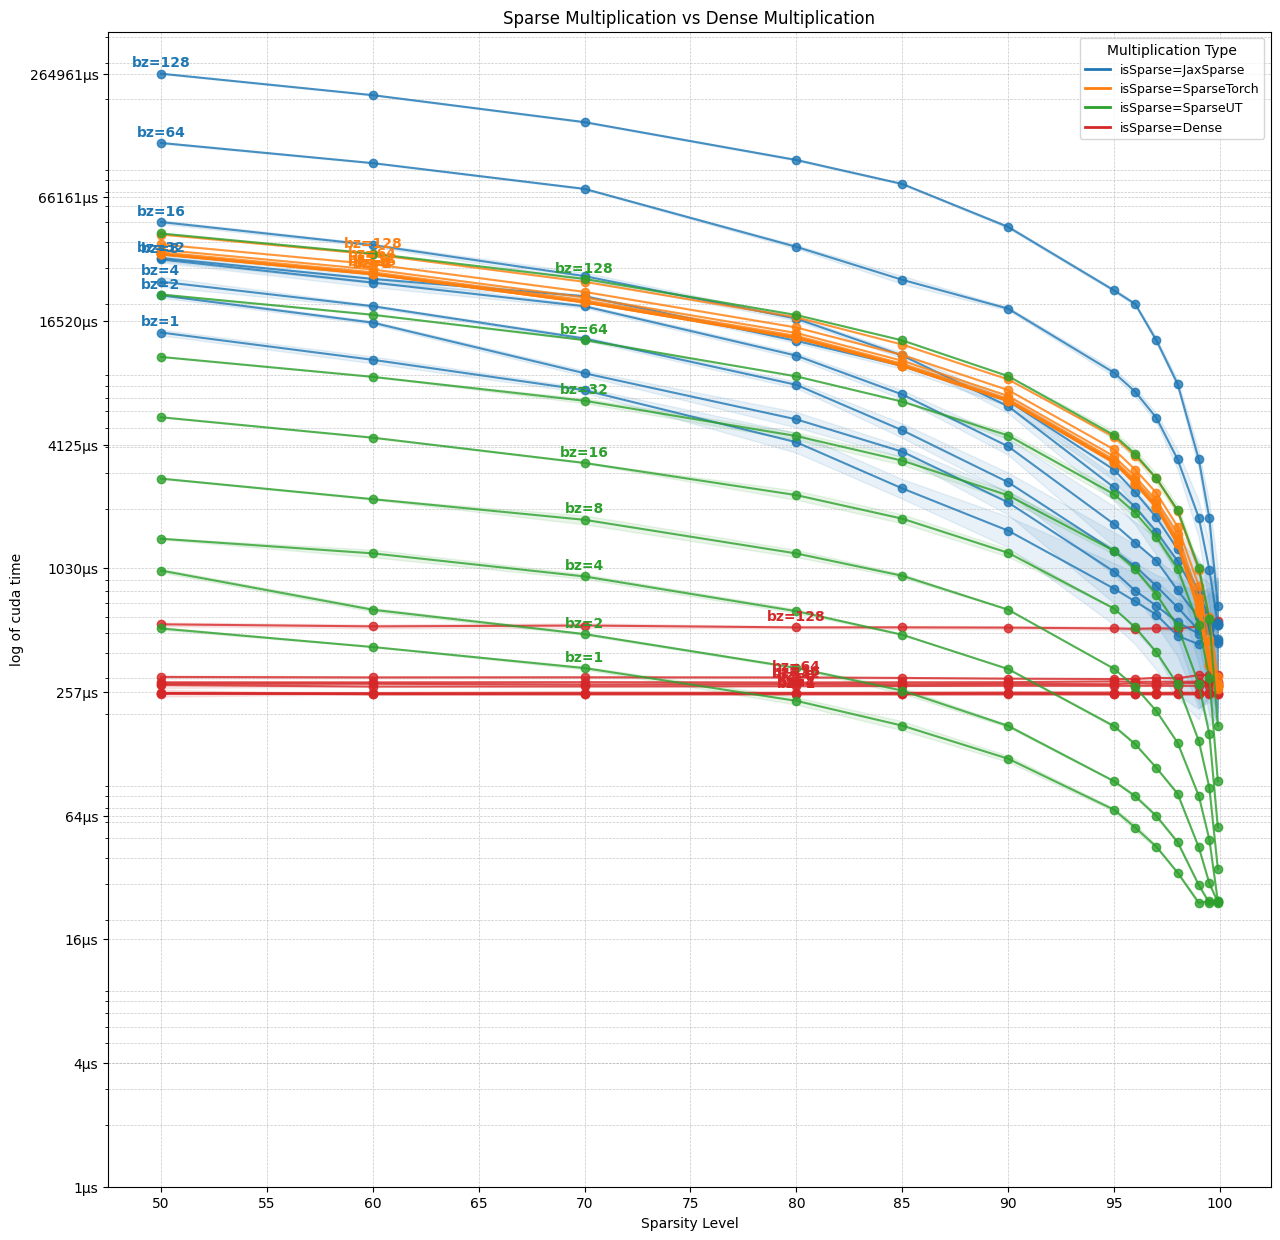

In [7]:
import seaborn as sns
fig, ax = plt.subplots(1,3,figsize=(21, 5));
import matplotlib.pyplot as plt
import numpy as np

def plt_them(df_dlvl, ax=None, tot=4, x_title=None, log=False):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    max_min_avg_s = 0
    colors = plt.cm.tab10.colors  # Assign colors per isSparse
    color_map = {category: colors[i] for i, category in enumerate(['JaxSparse', 'SparseTorch', 'SparseUT', 'Dense'])}
    idx_map = {category: i for i, category in enumerate(['JaxSparse', 'SparseTorch', 'SparseUT', 'Dense'])}

    for is_sparse, group_sparse in df_dlvl.groupby('isSparse'):
        for batch_size, group_batch in group_sparse.groupby('batch_size'):
            avg_per_sparsity = group_batch.groupby('sparsity_level')['cuda_elapsed_time'].mean() * 10
            std_per_sparsity = group_batch.groupby('sparsity_level')['cuda_elapsed_time'].std() * 10
            sparsity_level = group_batch.groupby('sparsity_level')['sparsity_level'].first()
            max_min_avg_s = max(max_min_avg_s, avg_per_sparsity.max())

            ax.plot(sparsity_level, avg_per_sparsity, linestyle='-', marker='o', 
                    color=color_map[is_sparse], alpha=0.8)
            ax.fill_between(sparsity_level, avg_per_sparsity - std_per_sparsity, 
                            avg_per_sparsity + std_per_sparsity, alpha=0.1, color=color_map[is_sparse])

            # Annotate batch size on the middle of the line
            mid_idx = len(sparsity_level) // 2
            ax.annotate(f'bz={batch_size}', 
                        (sparsity_level.iloc[idx_map[is_sparse]], avg_per_sparsity.iloc[idx_map[is_sparse]]), 
                        textcoords="offset points", xytext=(0, 5), ha='center', fontsize=10, 
                        color=color_map[is_sparse], fontweight='bold')

    ax.set_xticks(list(range(int(df_dlvl.sparsity_level.min()), 101, 5)))

    if log:
        ax.set_yscale("log")  # Set Y-axis to logarithmic scale
        yticks = np.geomspace(1, max_min_avg_s, num=10)  # Log-spaced ticks
        ax.set_yticks(yticks)
        ax.set_yticklabels([f"{int(t)}μs" for t in yticks])  # Custom labels with time units
    else:
        ax.set_yticks(np.linspace(0, max_min_avg_s, 20))

    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

    ax.set_title('Sparse Multiplication vs Dense Multiplication')
    ax.set_xlabel('Sparsity Level')
    ax.set_ylabel(x_title or 'Cuda Time (in microseconds)')

    # Custom legend for isSparse categories
    handles = [plt.Line2D([0], [0], color=color_map[cat], lw=2, label=f'isSparse={cat}') 
               for cat in color_map.keys()]
    ax.legend(handles=handles, title='Multiplication Type', loc='upper right', fontsize=9)


    return ax
def create_multi_plot_for_batches(BATCHES, log=False):
    fig, ax = plt.subplots(1,3,figsize=(21, 5));

    df_dlvl = df[(df.dense_level == dense_level) & (df.batch_size.isin(BATCHES))]
    df_dlvl['cuda_elapsed_time'] = df_dlvl['cuda_elapsed_time']
    plt_them(df_dlvl, ax=ax[0])
    
    
    plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
    
    # Group by the 'category' column and plot each group
    df_dlvl=df_dlvl[df_dlvl.isSparse != 'SparseTorch']
    plt_them(df_dlvl, ax=ax[1])
    
    
    
    plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
    
    # Group by the 'category' column and plot each group
    df_dlvl=df_dlvl[~df_dlvl.isSparse.isin(['SparseTorch', 'JaxSparse'])]
    plt_them(df_dlvl, ax[2])
    plt.show()
def create_single_plot_for_batches(BATCHES, log=False):
    fig, ax = plt.subplots(1,figsize=(15, 15));

    df_dlvl = df[(df.dense_level == dense_level) & (df.batch_size.isin(BATCHES))]
    df_dlvl['cuda_elapsed_time'] = df_dlvl['cuda_elapsed_time']# .apply(lambda x: np.log2(x))
    plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
    plt_them(df_dlvl, ax=ax, x_title="log of cuda time", log=2)
    plt.show()
#create_multi_plot_for_batches([1,2, 4])
create_single_plot_for_batches([1,2, 4, 8, 16, 32, 64, 128], log=True)






In [ ]:

fig, ax = plt.subplots(1,3,figsize=(21, 5));
bz = 1
df_dlvl = df[(df.dense_level == dense_level) & (df.batch_size == bz)]
print(df_dlvl.shape)
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

def plt_them(df_dlvl, ax=None):

    
    max_min_avg_s = 0
    
        
    for category, group in df_dlvl.groupby('isSparse'):
        avg_per_sparsity = group.groupby('sparsity_level')['cuda_elapsed_time'].mean() * 10
        std_per_sparsity = group.groupby('sparsity_level')['cuda_elapsed_time'].std() * 10
        sparsity_level = group.groupby('sparsity_level')['sparsity_level'].first()
        max_min_avg_s = max(max_min_avg_s, avg_per_sparsity.max())
        
        ax.plot(sparsity_level, avg_per_sparsity, marker='o', linestyle='-', label=category)
        ax.fill_between(sparsity_level, avg_per_sparsity - std_per_sparsity, avg_per_sparsity + std_per_sparsity, alpha=0.2)

    ax.set_xticks(list(range(int(df_dlvl.sparsity_level.min()), 100, 5)))
    ax.set_yticks(np.linspace(0, max_min_avg_s, 20))
    
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
    
    ax.set_title(f'Sparse Multiplication vs Dense Multiplication ({dense_level})')
    ax.set_xlabel('Sparsity Level')
    ax.set_ylabel('Cuda Time (in microseconds)')
    
    ax.legend(title='Multiplication Type')

    
    #return fig, ax  # Return figure and axis
plt_them(df_dlvl, ax=ax[0])

df_dlvl = df_dlvl[df_dlvl.dense_level == dense_level] 

plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# Group by the 'category' column and plot each group
df_dlvl=df_dlvl[df_dlvl.isSparse != 'SparseTorch']
plt_them(df_dlvl, ax=ax[1])



plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# Group by the 'category' column and plot each group
df_dlvl=df_dlvl[~df_dlvl.isSparse.isin(['SparseTorch', 'JaxSparse'])]
plt_them(df_dlvl, ax[2])
display(df_dlvl)